# 05 · Ordinary differential equations

Three single equations: the forced oscillator, the Van der Pol oscillator and the
forced Duffing oscillator. Each section shows the data, the signal check at 0, 1
and 5 % noise, a search on clean data with the selected equation compared to the
record, and a search at 5 % noise.

**How to read the comparison.** The upper panel puts the left-hand side of the
selected equation, computed from the data, next to the value the equation
predicts from its right-hand side. For ordinary differential equations written
as "highest derivative = function of the state", the lower panel integrates the
equation from the first point of the record and compares the solution with the
data; there errors accumulate, so this is the stricter test. When the selected
equation is not of that form, only the upper panel is shown. A close match of the
two sides alone does not prove the law: an identity of the record or a rearranged
equation can match as well, so the set of terms is compared with the known law
separately.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


## Forced oscillator with time-dependent damping

$$u'' + \sin(2t)\,u' + 4u = 1.5\,t$$

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.


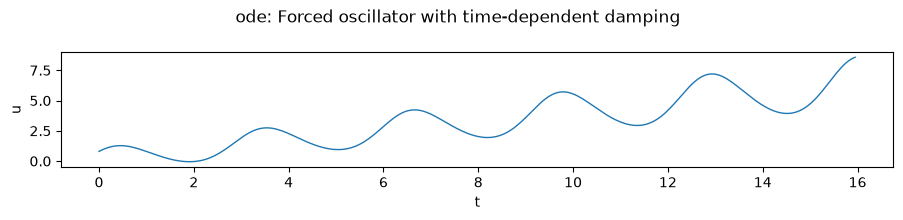

In [2]:
p = datasets.load('ode')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('ode', noise_levels=[0, 1, 5])
print_check(p, report)

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 0.999831   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    -4      -3.9845            9.119e-01
  du/dx0{'power': 1.0} * sin{'dim': 0.0, 'power': 1.0, 'freq         -1     -0.98892            5.823e-02
  x{'dim': 0.0, 'power': 1.0}                                       1.5       1.4974            5.044e-01

=== noise 1 % ===
R^2 of the true structure: 0.433371   (d^2u/dx0^2{power: 1.0})
  term            

In [4]:
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
print_run(rec)

ok

 fit 37 s (from cache)
[0] <- compromise pick
     -3.984485683554886 * u{power: 1.0} + 1.496973458999215 * x{power: 1.0, dim: 0.0} + -0.9885206385764294 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.005791878178457512}


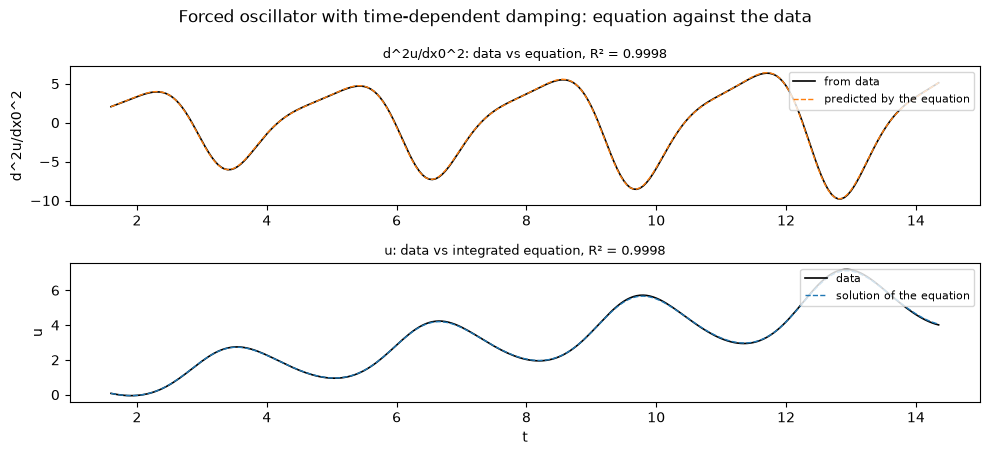

{'d^2u/dx0^2{power: 1.0}': 0.9998, 'trajectory u': 0.9998}


In [5]:
problem = datasets.load('ode')
search_cfg = resolve_for_problem(load_config('ode'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [6]:
rec = cached_run('ode', variant='default', noise=5.0, seed=0)
print_run(rec)

ok fit 34 s (from cache)
[0] <- compromise pick
     0.3776719262905246 * du/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.026752185511043605 * u{power: 3.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.015931012500262246 * u{power: 3.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     2.296267887408089 * u{power: 1.0} * d^2u/dx0^2{power: 1.0} + 24.55562608132476 * u{power: 2.0} + -20.573826506859827 * u{power: 1.0} * x{power: 1.0, dim: 0.0} + 4.178285440518317 * x{power: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0} * x{power: 1.0, dim: 0.0}
{'front_size': 2, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


## Van der Pol oscillator

$$u'' = 0.2\,(1 - u^2)\,u' - u$$

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.


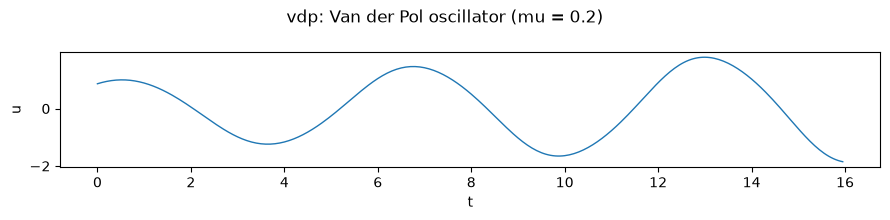

In [7]:
p = datasets.load('vdp')
print(p.summary())
plot_problem(p); plt.show()

In [8]:
p, report = check('vdp', noise_levels=[0, 1, 5])
print_check(p, report)

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0} * u{'power': 2.0}                           -0.2     -0.19902            1.745e-02
  du/dx0{'power': 1.0}                                              0.2      0.19933            1.975e-02
  u{'power': 1.0}                                                    -1     -0.99957            9.775e-01

=== noise 1 % ===
R^2 of the true structure: 0.142966   (d^2u/dx0^2{power: 1.0})
  term                                                      

In [9]:
rec = cached_run('vdp', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 71 s (from cache)
[0] <- compromise pick
     0.1993272458603458 * du/dx0{power: 1.0} + -0.19902156571275761 * du/dx0{power: 1.0} * u{power: 2.0} + -0.9995698877465794 * u{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0028953514626345322}


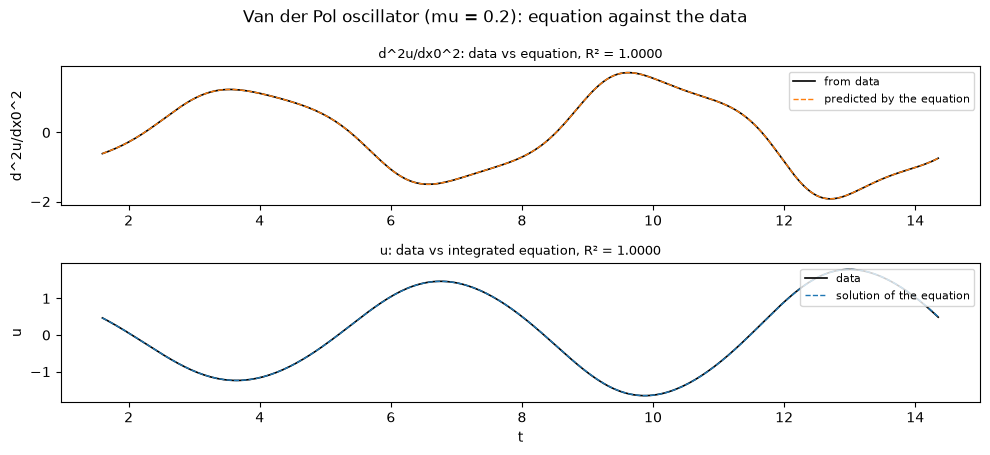

{'d^2u/dx0^2{power: 1.0}': 1.0, 'trajectory u': 1.0}


In [10]:
problem = datasets.load('vdp')
search_cfg = resolve_for_problem(load_config('vdp'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [11]:
rec = cached_run('vdp', variant='default', noise=5.0, seed=0)
print_run(rec)

ok fit 67 s (from cache)
[0]
     0.10758555645810121 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + -0.0839714248541288 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     0.10055168184353737 * u{power: 2.0} * x{power: 1.0, dim: 0.0} + -0.1919939301089809 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + -0.012609848342927681 * x{power: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
[2] <- compromise pick
     0.00895608186282936 * x{power: 2.0, dim: 0.0} + -0.005564932540603038 * x{power: 2.0, dim: 0.0} * u{power: 2.0} + 0.16440101294320794 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 2, 'success_front': False, 'success_selected': False, 'hamming_min': 7, 'hamming_selected': 8, 'coef_error': None}


## Forced Duffing oscillator

$$u'' + 0.2\,u' + u + u^3 = 0.3\cos t$$

The parameters are stored in the data file.

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); the parameters are stored in the data file.


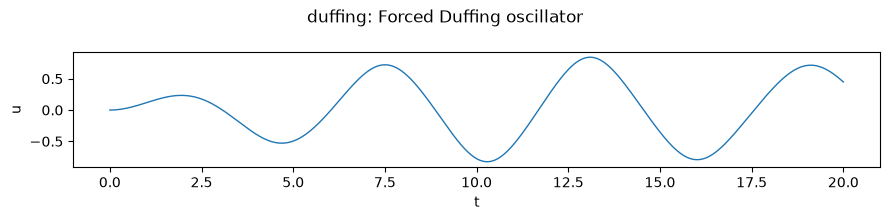

In [12]:
p = datasets.load('duffing')
print(p.summary())
plot_problem(p); plt.show()

In [13]:
p, report = check('duffing', noise_levels=[0, 1, 5])
print_check(p, report)

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); the parameters are stored in the data file.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0}                                             -0.2     -0.19988            1.137e-02
  u{'power': 1.0}                                                    -1      -1.0003            9.384e-02
  u{'power': 3.0}                                                    -1     -0.99866            2.239e-02
  cos{'dim': 0.0, 'power': 1.0, 'freq': 1.0

In [14]:
rec = cached_run('duffing', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 90 s (from cache)
[0] <- compromise pick
     -0.42740229414932496 * d^2u/dx0^2{power: 2.0} + -0.5707580731150578 * u{power: 2.0} + 0.0 = u{power: 1.0} * d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


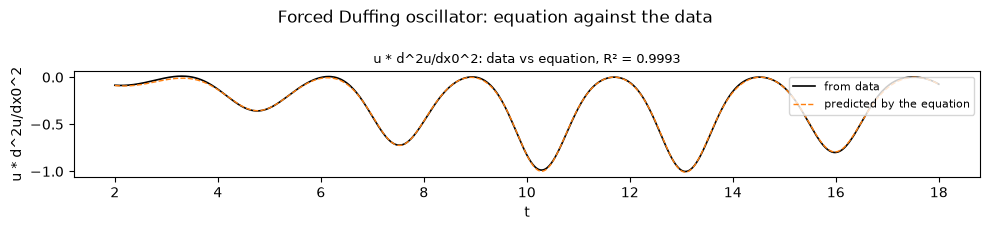

{'u{power: 1.0} * d^2u/dx0^2{power: 1.0}': 0.9993}


In [15]:
problem = datasets.load('duffing')
search_cfg = resolve_for_problem(load_config('duffing'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [16]:
rec = cached_run('duffing', variant='default', noise=5.0, seed=0)
print_run(rec)

ok

 fit 273 s (from cache)
[0]
     -0.00974686521533911 * u{power: 1.0} * x{power: 2.0, dim: 0.0} + 0.12606074697526562 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 1.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0}
[1] <- compromise pick
     0.02284055368677974 * x{power: 1.0, dim: 0.0} + -0.03433220133486359 * x{power: 1.0, dim: 0.0} * u{power: 2.0} + 0.5271984616628808 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[2]
     -0.03467351168629306 * x{power: 1.0, dim: 0.0} * u{power: 2.0} + -0.0004872078088334357 * d^2u/dx0^2{power: 1.0} * cos{power: 1.0, freq: 1.0, dim: 0.0} + 0.5274595661250028 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 0.022935800980566936 * x{power: 1.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 1, 'success_front': False, 'success_selected': False, 'hamming_min': 6, 'hamming_selected': 9, 'coef_error': None}
